**Jack Dai**

Spring 2026

CS 251/2: Data Analysis and Visualization

Project 3: Linear regression

#### Week 2: Polynomial regression


In [14]:
import numpy as np
import matplotlib.pyplot as plt

import data
import linear_regression

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CS252 Note

For full credit, please use your Normal Equations least squares solver throughout this notebook.


## Task 3: Polynomial Regression


We have been creating linear regression fits of form $y =c_0 + c_1x_1 + c_2x_2 + \ldots$, where $x_i$ are independent variables (columns of $A$) and $c_i$ are corresponding coefficients in $c$. However, this equation only allows us to fit data with a line/plane. This may not be the best choice for all datasets.

In this task, you will generalize the linear regression model form to include higher-degree (>1) polynomial terms and explore how this may improve fits to complex data. For example, assume we're doing a simple linear regression with independent variable $x_1$ and dependent variable $y$. A linear regression that fits data with a quadratic shape has the form$$y = c_0 + c_1x_1 + c_2x_1^2$$

Complete the following steps to add support for polynomial regression in your `LinearRegression` class.


### 3a. Build the polynomial matrix of the independent variable

The polynomial matrix contains the independent variable raised to a different power in each column. For example, if $A$ originally has a column vector for the independent variable $\vec{x_1}$ ($A = [\vec{x_1}]$) and we wanted to make the above quadratic model, we would append $x_1^2$ ($A = [\vec{x_1}, \vec{x_1^2}]$).

**TODO:**
Implement and test `LinearRegression::make_polynomial_matrix` (_helper method_) that takes care of raising the independent variable samples to different powers.

##### Test `make_polynomial_matrix`


In [15]:
test_A = np.r_[1:10].reshape((9, 1))
test_p = 3

# Test cubic
lin_reg = linear_regression.LinearRegression(data.Data())
print(f'Your polynomial matrix:\n{lin_reg.make_polynomial_matrix(test_A, 3)}')

true_mat = '''
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]
'''
print('It should look like:\n', true_mat)



Your polynomial matrix:
[[  1   1   1]
 [  2   4   8]
 [  3   9  27]
 [  4  16  64]
 [  5  25 125]
 [  6  36 216]
 [  7  49 343]
 [  8  64 512]
 [  9  81 729]]
It should look like:
 
[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]
 [  6.  36. 216.]
 [  7.  49. 343.]
 [  8.  64. 512.]
 [  9.  81. 729.]]



### 3b. Add support for polynomial regression

This can be performed in 3 steps:

1. Implement the `LinearRegression::polynomial_regression` method to perform the polynomial regression (_alternate option: you may instead update your `linear_regression` method. If you decide to go this route, add a keyword argument for the polynomial degree with a default value of 1 to preserve compatability with regular linear regression._).
2. Update `LinearRegression::predict`: Run `make_polynomial_matrix` on the "A" matrix that enters into the computation $y = Ac$ if `self.p > 1`.
3. Add support for plotting polynomials in `LinearRegression::scatter` by generalizing the plotted regression line to a regression polynomial if `self.p > 1`:
   - Getting your polynomial "x" values: Run `make_polynomial_matrix` on your evenly-spaced line sample points. To get the shapes to work out, you may need to add a trailing singleton dimension to your "x" sample points. For example, if you have 1000 "x" sample points, make the shape `(1000, 1)` rather than `(1000,)`.
   - Getting your polynomial "y" values: Use matrix multiplication with your polynomial regression model slopes and/or intercepts.

_There is no explicit test code here â€” visualizing the fit in the next subtask will help you debug!_


### 3c. Test polynomial regression with linear and cubic models

This subtask will help to make sure your polynomial regression implementation is working.

1. In the cell below, fit the `wave_fit.csv` dataset using polynomial regression where the polynomial degree $p = 1$ and separately with $p = 10$.
2. Use `scatter` to plot the results.
3. Print out the mean squared error.

The plot for the $p=1$ regression should "look right" to you and the $p=10$ fit should show visually distinct "wiggles".


In [16]:
poly_data_filename = 'data/wave_fit.csv'
poly_data = data.Data(poly_data_filename)
print(poly_data)

-------------------------------
data/wave_fit.csv (150x2)
Headers:
  x	y
-------------------------------
Showing first 5/150 rows.
2.0858	-0.4942
4.6724	-5.85
2.4812	-3.3264
0.2579	4.5996
-0.9518	4.9771

-------------------------------


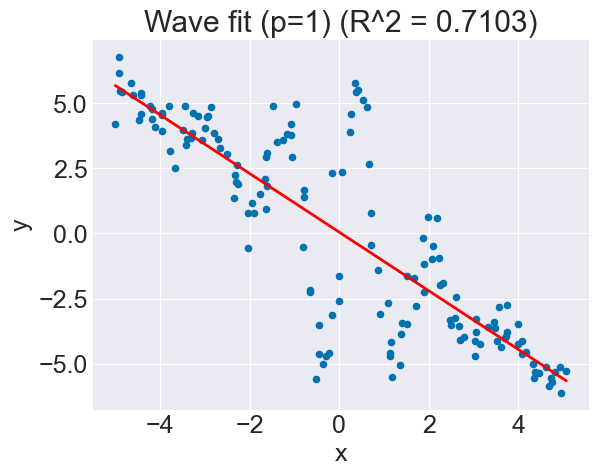

p=1 MSE: 4.402518022533747


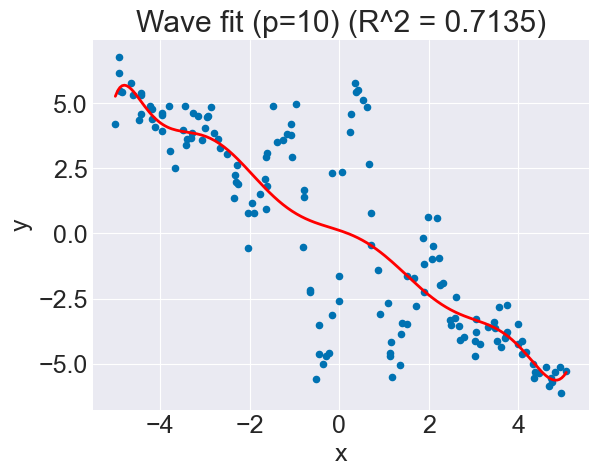

p=10 MSE: 4.353802650593321


In [17]:
# YOUR CODE HERE
lin_reg_p1 = linear_regression.LinearRegression(poly_data)
lin_reg_p1.poly_regression('x', 'y', 1, method='normal')
lin_reg_p1.scatter('x', 'y', 'Wave fit (p=1)')
plt.show()
print(f'p=1 MSE: {lin_reg_p1.mse}')

lin_reg_p10 = linear_regression.LinearRegression(poly_data)
lin_reg_p10.poly_regression('x', 'y', 10, method='normal')
lin_reg_p10.scatter('x', 'y', 'Wave fit (p=10)')
plt.show()
print(f'p=10 MSE: {lin_reg_p10.mse}')

### 3d.Polynomial regression with higher degree polynomials

Repeat the steps from the previous subtask, but this time find the smallest polynomial degree that gives you a $R^2 > 0.76$.

Make a plot showing the fitted data with the polynomial that you find.

_Your regression fit should not be a line!_


Chosen p: 15, R2: 0.7610786158454188


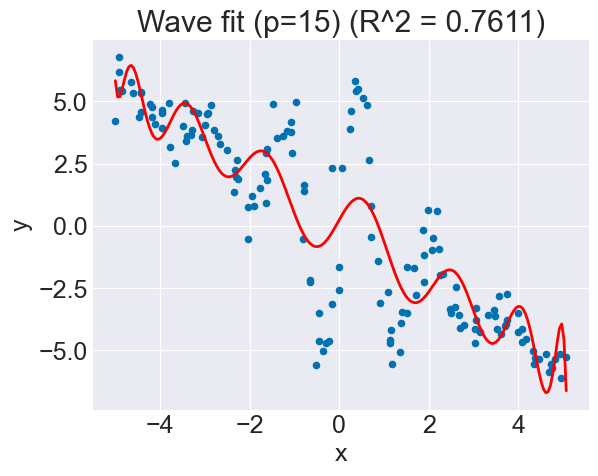

In [25]:
# YOUR CODE HERE
p_best = None
best_lr = None

for p in range(1, 21):
    lr = linear_regression.LinearRegression(poly_data)
    lr.poly_regression('x', 'y', p, method='normal')
    if lr.R2 > 0.76:
        p_best = p
        best_lr = lr
        break

if p_best is None:
    p_best = 20
    best_lr = lr

print(f'Chosen p: {p_best}, R2: {best_lr.R2}')
best_lr.scatter('x', 'y', f'Wave fit (p={p_best})')
plt.show()

### 3e. Questions


**Question 4:** Is the fit better or worse compared to what you found in Task 3c? Why?


**Answer 4:**


Better in terms of $R^2$ because we increased model flexibility to meet the $R^2>0.76$ target, though the curve is also more wiggly and closer to overfitting.


**Question 5:** Describe what happens visually to the shape of the regression curve and in relation to the data as you experiment with the polynomial degree between 1 and the polynomial degree that you found.


**Answer 5:**


As $p$ increases, the curve bends more to follow the data, starting from a straight line and becoming increasingly wavy; it fits training points more tightly but also starts to oscillate and can overfit noise.


### 3f. Fit error analysis

Create a plot showing the MSE values as the polynomial degree goes from 1 to the polynomial degree that you found above.


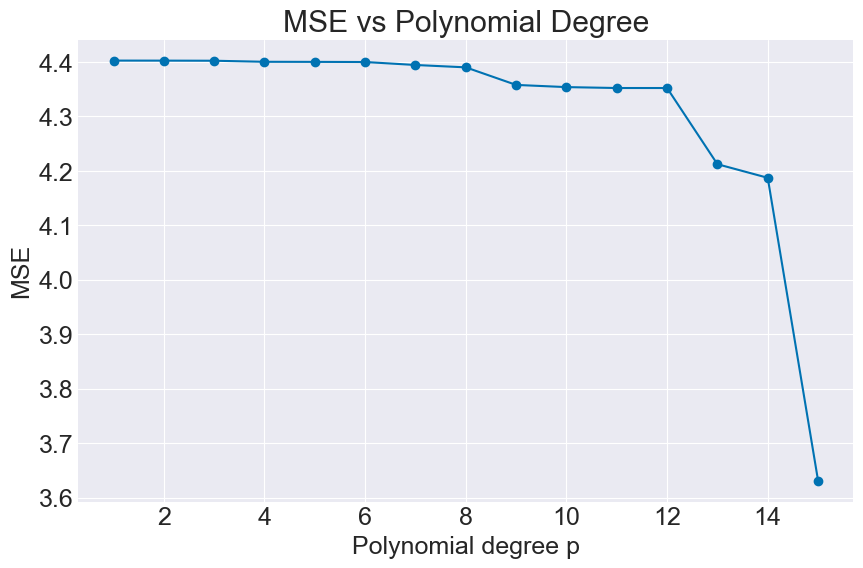

In [19]:
# YOUR CODE HERE
p_vals = range(1, p_best + 1)
mse_by_p = []

for p in p_vals:
    lr = linear_regression.LinearRegression(poly_data)
    lr.poly_regression('x', 'y', p, method='normal')
    mse_by_p.append(lr.mse)

plt.figure(figsize=(10, 6))
plt.plot(list(p_vals), mse_by_p, marker='o')
plt.xlabel('Polynomial degree p')
plt.ylabel('MSE')
plt.title('MSE vs Polynomial Degree')
plt.show()

### 3g. Questions

**Question 6:** According to the MSE, is the fit generally improving or worsening as $p$ increases?


**Answer 6:**


It generally improves (MSE decreases) as $p$ increases on the training data, though the gains diminish and can eventually risk overfitting.


## Task 4: Overfitting

In this subtask, you will experiment with how polynomial regression generalize to data not used to fit the regression model.


### 4a. Create fit and validation sets

The `wave.csv` dataset has 300 samples ($N=300$). In the cell below, split these samples into two separate "datasets" and create 2 `Data` objects representing:

- The first 50% of samples will be used to fit the regression model (i.e. run linear regression on these samples). We will call this the **fit set** (data used to fit the regression).
- The second 50% of samples will be set aside and only used to check how well the fitted regression generalizes to new data. We will call this the **validation set**.

The data samples are already shuffled.

_Hint: There is a helpful `Data` method for paring down a dataset into a certain range of samples._


In [20]:
# YOUR CODE HERE
wave_data = data.Data('data/wave.csv')
num_samples = wave_data.get_num_samples()
mid = num_samples // 2

data_fit = data.Data('data/wave.csv')
data_val = data.Data('data/wave.csv')

data_fit.limit_samples(0, mid)
data_val.limit_samples(mid, num_samples)

#### Test: Fit and validation sets


In [21]:
# NOTE: The Data object containing the fit dataset in the test below is called `data_fit`
# The The Data object containing the validation dataset in the test below is called `data_val`
print(f'The first sample of the fit data is\n{data_fit.get_sample(0)} and it should be')
print('[-4.5635  5.0392]')
print(f'The last sample of the fit data is\n{data_fit.get_sample(149)} and it should be')
print('[ 1.2476 -3.9375]')
print(f'The first sample of the val data is\n{data_val.get_sample(0)} and it should be')
print('[-0.7677 -2.8413]')
print(f'The last sample of the val data is\n{data_val.get_sample(149)} and it should be')
print('[ 4.1889 -3.9513]')

The first sample of the fit data is
[-4.5635  5.0392] and it should be
[-4.5635  5.0392]
The last sample of the fit data is
[ 1.2476 -3.9375] and it should be
[ 1.2476 -3.9375]
The first sample of the val data is
[-0.7677 -2.8413] and it should be
[-0.7677 -2.8413]
The last sample of the val data is
[ 4.1889 -3.9513] and it should be
[ 4.1889 -3.9513]


### 4b. Copying fitted regression coefficients

Because we fit the polynomial regression on the fit set, the fitted coefficients are stored in the fit set, `LinearRegression` object. To visualize the predictions on the validation set, we will need to first copy over the coefficients from the fit set `LinearRegression` object to the validation set `LinearRegression` object.

Implement the following methods to accomplish this:

- `get_fitted_slope`: return the fitted regression slopes.
- `get_fitted_intercept`: return the fitted regression intercept.
- `initialize(ind_vars, dep_var, slope, intercept, p)`: set fields based on passed in parameter values.


### 4c. Check fit generalization on validation set

In the cell below, fit a degree 20 polynomial regression model to the fit set and assess generalization on the validation set.

Checklist for what to include:

1. Fit a polynomial regression model with polynomial degree 20 on the fit set.
2. Create 2 scatter plots:
   - Showing the fit set and regression curve fitted to it.
   - Showing the validation set and regression curve that uses the fitted coefficients to the **fit set**.
3. Compute and print the MSE for both the fit and validation sets.


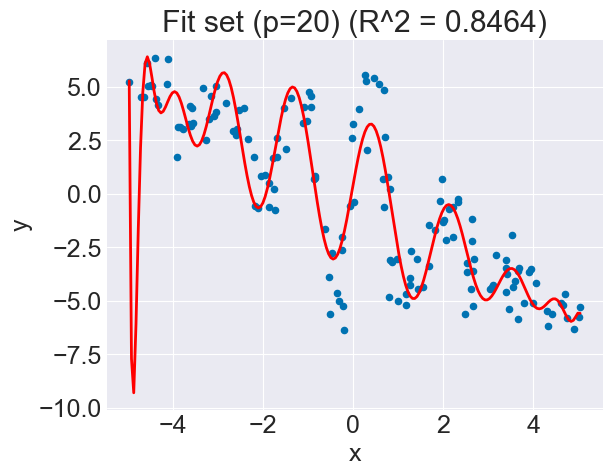

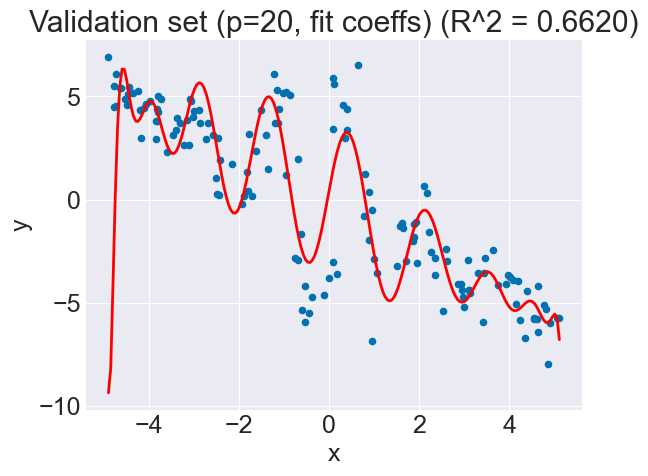

Fit MSE: 2.2140144779159487
Val MSE: 5.627534237377841


In [22]:
# YOUR CODE HERE
lin_fit = linear_regression.LinearRegression(data_fit)
lin_fit.poly_regression('x', 'y', 20, method='normal')
lin_fit.scatter('x', 'y', 'Fit set (p=20)')
plt.show()

lin_val = linear_regression.LinearRegression(data_val)
lin_val.initialize(['x'], 'y', lin_fit.get_fitted_slope(), lin_fit.get_fitted_intercept(), 20)
lin_val.scatter('x', 'y', 'Validation set (p=20, fit coeffs)')
plt.show()

print(f'Fit MSE: {lin_fit.mse}')
print(f'Val MSE: {lin_val.mse}')

### 4d. Questions


**Question 7:** How do the fitted coefficients obtained for the fit set generalize to the validation set. Why?


**Answer 7:**


They generalize poorly at high degree: the fit set coefficients capture noise/oscillations, so validation error is higher and the curve is less stable on unseen data.


### 4e. Acceptable generalization

Find a polynomial degree that you believe yields acceptable generalization to the validation set. Make a plot and report several metrics that justify your finding.

**Note:** Base your decision making upon the metrics, even though you might think the visual appearance is not "ideal".


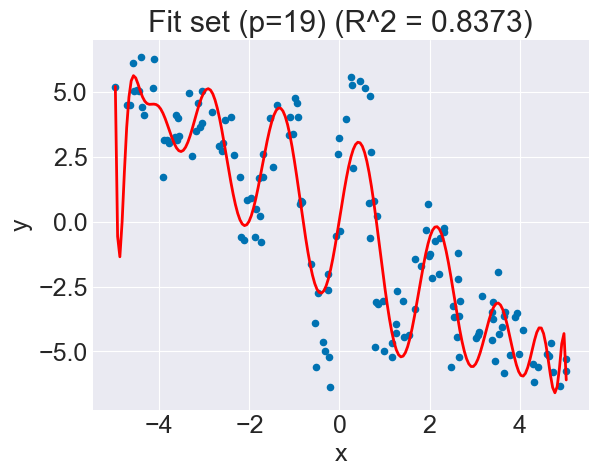

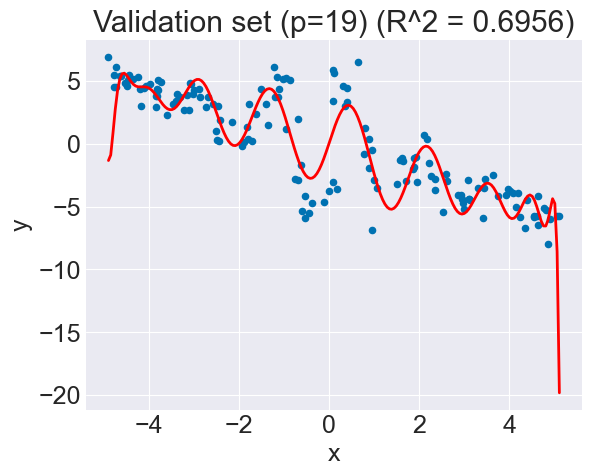

In [23]:
# YOUR CODE HERE
deg_candidates = range(1, 21)
fit_mse_list = []
val_mse_list = []
models = []

for p in deg_candidates:
    lr_fit = linear_regression.LinearRegression(data_fit)
    lr_fit.poly_regression('x', 'y', p, method='normal')
    lr_val = linear_regression.LinearRegression(data_val)
    lr_val.initialize(['x'], 'y', lr_fit.get_fitted_slope(), lr_fit.get_fitted_intercept(), p)
    fit_mse_list.append(lr_fit.mse)
    val_mse_list.append(lr_val.mse)
    models.append((lr_fit, lr_val))

best_idx = int(np.argmin(val_mse_list))
best_deg = list(deg_candidates)[best_idx]
best_fit_model, best_val_model = models[best_idx]

best_fit_model.scatter('x', 'y', f'Fit set (p={best_deg})')
plt.show()
best_val_model.scatter('x', 'y', f'Validation set (p={best_deg})')
plt.show()

In [24]:
# YOUR CODE HERE
print(f'Best degree: {best_deg}')
print(f'Fit MSE: {best_fit_model.mse}')
print(f'Val MSE: {best_val_model.mse}')
print(f'Fit R2: {best_fit_model.R2}')
print(f'Val R2: {best_val_model.R2}')

Best degree: 19
Fit MSE: 2.34479737856589
Val MSE: 5.067238724804366
Fit R2: 0.8373469088710894
Val R2: 0.6956461351447317
